In [9]:
import pandas as pd
df = pd.read_csv("../data/NY-House-Dataset.csv")
print(df.head())

                                         BROKERTITLE                TYPE  \
0        Brokered by Douglas Elliman  -111 Fifth Ave      Condo for sale   
1                                Brokered by Serhant      Condo for sale   
2                             Brokered by Sowae Corp      House for sale   
3                                Brokered by COMPASS      Condo for sale   
4  Brokered by Sotheby's International Realty - E...  Townhouse for sale   

       PRICE  BEDS       BATH  PROPERTYSQFT  \
0     315000     2   2.000000        1400.0   
1  195000000     7  10.000000       17545.0   
2     260000     4   2.000000        2015.0   
3      69000     3   1.000000         445.0   
4   55000000     7   2.373861       14175.0   

                                             ADDRESS                    STATE  \
0                               2 E 55th St Unit 803       New York, NY 10022   
1  Central Park Tower Penthouse-217 W 57th New Yo...       New York, NY 10019   
2                


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Users\Asus\AppData\Local\Temp\ipykernel_26988\999626839.py:57: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_cleaned = df.groupby('SUBLOCALITY_CLEAN').apply(lambda x: remove_outliers_iqr(x, 'PRICE')).reset_index(drop=True)
C:\Users\Asus\AppData\Local\Temp\ipykernel_26988\999626839.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns

เริ่มต้นกระบวนการ Data Pipeline สำหรับ NY Deal Hunter...
เซฟและดาวน์โหลดไฟล์ NY_House_Cleaned.csv เรียบร้อย!
กำลังสอน AI ให้ประเมินราคา...

🎯 ความแม่นยำรวม (R-squared): 74.79%
💵 คลาดเคลื่อนเฉลี่ย (MAE): $260,838.17



C:\Users\Asus\AppData\Local\Temp\ipykernel_26988\999626839.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(10), palette='viridis')


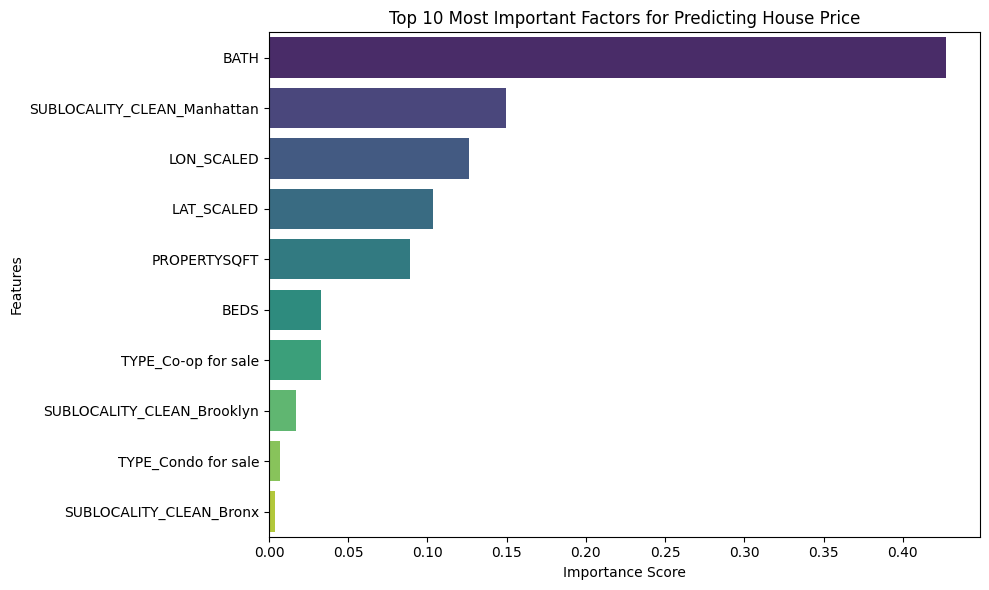

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
!{sys.executable} -m pip install seaborn
import seaborn as sns
import sys
!{sys.executable} -m pip install scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

df = pd.read_csv("../data/NY-House-Dataset.csv")

print("เริ่มต้นกระบวนการ Data Pipeline สำหรับ NY Deal Hunter...")

# ==========================================
# STEP 1: โหลดและทำความสะอาดพื้นฐาน
# ==========================================

df = df.drop_duplicates()

cols_to_check = ['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'LATITUDE', 'LONGITUDE', 'TYPE', 'SUBLOCALITY']
df = df.dropna(subset=cols_to_check)

# ==========================================
# STEP 2: จัดระเบียบข้อมูล (Data Transformation)
# ==========================================
allowed_types = ['Condo for sale', 'House for sale', 'Townhouse for sale', 'Co-op for sale', 'Multi-family home for sale']
df = df[df['TYPE'].isin(allowed_types)]

def clean_borough(name):
    name = str(name).lower()
    if any(x in name for x in ['bronx', 'riverdale', 'the bronx']): return 'Bronx'
    if any(x in name for x in ['brooklyn', 'kings', 'coney island', 'dumbo', 'snyder avenue']): return 'Brooklyn'
    if any(x in name for x in ['manhattan', 'new york']): return 'Manhattan'
    if any(x in name for x in ['queens', 'flushing', 'jackson heights', 'rego park']): return 'Queens'
    if any(x in name for x in ['staten island', 'richmond']): return 'Staten Island'
    return 'Other'

df['SUBLOCALITY_CLEAN'] = df['SUBLOCALITY'].apply(clean_borough)
df = df[df['SUBLOCALITY_CLEAN'] != 'Other']

# ==========================================
# STEP 3: กำจัดตัวเลขผิดปกติ (Hybrid Outlier Removal)
# ==========================================
def remove_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]

df_cleaned = df.groupby('SUBLOCALITY_CLEAN').apply(lambda x: remove_outliers_iqr(x, 'PRICE')).reset_index(drop=True)
df_cleaned = df_cleaned.groupby('SUBLOCALITY_CLEAN').apply(lambda x: remove_outliers_iqr(x, 'PROPERTYSQFT')).reset_index(drop=True)

df_cleaned.to_csv('NY_House_Cleaned.csv', index=False)

df.to_csv("../data/NY_House_Cleaned.csv", index=False)
print("เซฟและดาวน์โหลดไฟล์ NY_House_Cleaned.csv เรียบร้อย!")

# ==========================================
# STEP 4: เตรียมข้อมูลให้ AI (Feature Engineering)
# ==========================================
scaler = MinMaxScaler()
df_cleaned[['LAT_SCALED', 'LON_SCALED']] = scaler.fit_transform(df_cleaned[['LATITUDE', 'LONGITUDE']])

df_encoded = pd.get_dummies(df_cleaned, columns=['TYPE', 'SUBLOCALITY_CLEAN'])

features_to_keep = ['BEDS', 'BATH', 'PROPERTYSQFT', 'LAT_SCALED', 'LON_SCALED']
type_cols = [col for col in df_encoded.columns if 'TYPE_' in col]
sub_cols = [col for col in df_encoded.columns if 'SUBLOCALITY_CLEAN_' in col]
final_features = features_to_keep + type_cols + sub_cols

X = df_encoded[final_features]
y = np.log1p(df_encoded['PRICE'])

# ==========================================
# STEP 5: สอนโมเดล AI (Machine Learning)
# ==========================================
print("กำลังสอน AI ให้ประเมินราคา...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ใช้ Random Forest Regressor สร้างต้นไม้ 150 ต้น
rf_model = RandomForestRegressor(n_estimators=150, max_depth=20, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# ==========================================
# STEP 6: วัดผลและแสดงผลลัพธ์
# ==========================================
y_pred_log = rf_model.predict(X_test)
y_pred_actual = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

r2 = r2_score(y_test_actual, y_pred_actual)
mae = mean_absolute_error(y_test_actual, y_pred_actual)

print("\n" + "="*40)
print(f"🎯 ความแม่นยำรวม (R-squared): {r2*100:.2f}%")
print(f"💵 คลาดเคลื่อนเฉลี่ย (MAE): ${mae:,.2f}")
print("="*40 + "\n")

# ==========================================
# STEP 7: พล็อตกราฟปัจจัยสำคัญ (Feature Importance)
# ==========================================
importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(10), palette='viridis')
plt.title('Top 10 Most Important Factors for Predicting House Price')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# ==========================================
# STEP 8: เซฟสมอง AI แล้วโหลดลงเครื่อง
# ==========================================
# print("💾 กำลังบันทึกไฟล์โมเดล...")
# joblib.dump(rf_model, 'deal_hunter_model.pkl')
# joblib.dump(scaler, 'my_scaler.pkl')

# files.download('deal_hunter_model.pkl')
# files.download('my_scaler.pkl')
# print("✅ ดาวน์โหลดสำเร็จ! นำไฟล์ไปใช้ใน VSCode ได้เลย!")



In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import joblib

rf_model = RandomForestRegressor(n_estimators=150, max_depth=20, random_state=42)

rf_model.fit(X_train, y_train)

joblib.dump(rf_model, "../app/ml_models/deal_hunter_model.pkl")


['../app/ml_models/deal_hunter_model.pkl']